# Preprocessing
In this notebook, we will create a pipeline which performs the following transformations on a
dataset passed through [`/filter_data.ipynb`](./filter_data.ipynb).

> As found in [`exploratory_data_analysis.ipynb`](./exploratory_data_analysis.ipynb), the agencies
> within **NYC311** feature vastly different scales and values depending on the agency. As such, we 
> will proceed by creating a pipeline for each model individually, set to the specific agencies
> datasets.

> We will fit our transformation pipeline using data from **NYC311**, in 2025.

| Feature | Null Response | Transformation | Notes |
|---|---|---|---|
| `problem` | — | One-hot encoding | |
| `detail`| Impute with "NoValue" | One-hot encoding | |
| `method`| Impute with "NoValue" | One-hot encoding | |
| `borough` | — | One-hot encoding | |
| `zipcode` | — | Target encoding, Standardization | |
| `c_month` | — | Cyclical encoding | Derived from `created` | 
| `c_day` | — | Cyclical encoding | Derived from `created` | 
| `c_hour`| — | Cyclical encoding | Derived from `created` | 


# Setup

In [31]:
# setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# grab data
df = pd.read_csv(
    '../data/nyc311_2025.csv', 
    index_col='id', 
    dtype={'zipcode': 'category'},
    parse_dates=['created', 'closed']
)

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 3475290 entries, 67351762 to 63577994
Data columns (total 11 columns):
 #   Column           Dtype         
---  ------           -----         
 0   created          datetime64[us]
 1   closed           datetime64[us]
 2   agency_name      str           
 3   problem          str           
 4   detail           str           
 5   borough          str           
 6   lat              float64       
 7   long             float64       
 8   method           str           
 9   zipcode          category      
 10  resolution_time  float64       
dtypes: category(1), datetime64[us](2), float64(3), str(5)
memory usage: 298.3 MB


## Extracting Agencies

In [34]:
# extract agency names
agency_names = df.agency_name.unique().tolist()
agency_names

['New York City Police Department',
 'Taxi and Limousine Commission',
 'Department of Housing Preservation and Development',
 'Department of Buildings',
 'Department of Transportation',
 'Department of Sanitation',
 'Department of Consumer and Worker Protection',
 'Department of Environmental Protection',
 'Department of Parks and Recreation',
 'Department of Health and Mental Hygiene',
 'Office of the Sheriff',
 'Department of Homeless Services',
 'Department of Education',
 'Office of Technology and Innovation',
 'Economic Development Corporation']

In [35]:
# separate df into agencies
agency_df = {}

for agency in agency_names:
    agency_df[agency] = df[df.agency_name == agency]

In [36]:
# sanity check
res1 = df[df.agency_name == ''] # empty clone
for key in agency_df.keys():
    res1 = pd.concat([res1, agency_df[key].head(1)])

res1

,created,closed,agency_name,problem,detail,borough,lat,long,method,zipcode,resolution_time
id,,,,,,,,,,,
67351762,2025-12-31 23:59:28,2026-01-01 00:40:32,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.792141,-73.950097,MOBILE,10029,0.684
67345192,2025-12-31 23:58:25,2026-01-02 11:55:46,Taxi and Limousine Commission,Lost Property,Bag/Wallet,MANHATTAN,40.738077,-73.992123,PHONE,10011,35.956
67350845,2025-12-31 23:57:56,2026-01-03 22:59:48,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,BROOKLYN,40.600602,-73.933754,PHONE,11229,71.031
67353895,2025-12-31 23:57:09,2026-03-02 00:00:00,Department of Buildings,Boilers,Boiler - Defective/Inoperative/No Permit,MANHATTAN,40.874848,-73.910831,UNKNOWN,10463,1440.048
67344470,2025-12-31 23:57:00,2026-01-09 01:53:00,Department of Transportation,Street Light Condition,Street Light Out,BRONX,40.871462,-73.830537,UNKNOWN,10475,193.933
67347694,2025-12-31 23:51:04,2026-01-02 12:28:44,Department of Sanitation,Illegal Dumping,Removal Request,QUEENS,40.662020,-73.775446,MOBILE,11434,36.628
67350123,2025-12-31 23:31:29,2026-02-01 04:01:36,Department of Consumer and Worker Protection,Consumer Complaint,Other Store (Non-Food),MANHATTAN,40.745620,-73.999285,ONLINE,10011,748.502
67352233,2025-12-31 23:26:00,2026-01-28 07:20:00,Department of Environmental Protection,Water System,No Water (WNW),STATEN ISLAND,40.642804,-74.078712,PHONE,10301,655.900
67349958,2025-12-31 23:16:33,2026-01-05 14:48:05,Department of Parks and Recreation,Damaged Tree,Branch or Limb Has Fallen Down,QUEENS,40.739975,-73.705165,ONLINE,11004,111.526


# Pipeline Creation
To ensure an easy process when defining our pipeline, we will first create a pipeline that transforms
only **NYPD** data. After our pipeline is created, we can fit and apply the changes to each and every
other agency as well.

In [37]:
df = agency_df['New York City Police Department']
df.head()

,created,closed,agency_name,problem,detail,borough,lat,long,method,zipcode,resolution_time
id,,,,,,,,,,,
67351762,2025-12-31 23:59:28,2026-01-01 00:40:32,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.792141,-73.950097,MOBILE,10029,0.684
67344624,2025-12-31 23:59:23,2026-01-01 01:03:42,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.825137,-73.949447,ONLINE,10031,1.072
67346873,2025-12-31 23:59:21,2026-01-01 00:58:13,New York City Police Department,Blocked Driveway,Partial Access,BROOKLYN,40.619995,-73.921167,PHONE,11234,0.981
67353004,2025-12-31 23:59:20,2026-01-01 00:57:31,New York City Police Department,Noise - Residential,Loud Music/Party,BROOKLYN,40.591542,-73.955979,ONLINE,11235,0.970
67350526,2025-12-31 23:59:12,2026-01-01 00:41:16,New York City Police Department,Noise - Commercial,Loud Music/Party,MANHATTAN,40.822593,-73.949525,MOBILE,10031,0.701


## Categorical Variables
Our first transformation will consist of a series of *One-hot encoding* transformations on `problem`,
`detail`, `method`, and `borough`. Note that `detail` and `method` will have their own pipeline, as
we would like to keep (impute) any potential missing data with `"NoValue"`. We ignore fields like
`problem` and `borough` as these are critical fields within the input, and cannot be left blank.

We will include an `infrequent` column, incase of rare problems, or details which are not captured
during training.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


cat_features = ['problem', 'borough', 'detail', 'method']

cat_pipeline_std = Pipeline([
    # there exists the rare, unknown case. in these examples, we will use a default column
    ('one-hot', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='infrequent_if_exist', min_frequency=1)) 
])

cat_pipeline_impute = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='NoValue')),
    # there exists the rare, unknown case. in these examples, we will use a default column
    ('one-hot', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='infrequent_if_exist', min_frequency=1))
])

cat_pipeline = ColumnTransformer([
    ('cat_std', cat_pipeline_std, ['problem', 'borough']),
    ('cat_impute', cat_pipeline_impute, ['detail', 'method'])],
    remainder='drop', # there should not be any, in the end we will use a column transformer 
    verbose_feature_names_out=False
)

# test
cat_test = df[cat_features]
cat_pipeline.fit(cat_test)
cat_test_res = cat_pipeline.transform(cat_test)

pd.DataFrame(cat_test_res.todense(), columns=cat_pipeline.get_feature_names_out()).head(2) # TODO changed to sparse

,problem_Animal-Abuse,problem_Bike/Roller/Skate,problem_Bike/Roller/Skate Chronic,problem_Blocked Driveway,problem_Disorderly Youth,problem_Drinking,problem_Drug Activity,problem_Encampment,problem_Graffiti,problem_Illegal Fireworks,...,detail_Underage - Licensed Est,detail_Unspecified,detail_Use Indoor,detail_Use Outside,detail_Vehicle,detail_With License Plate,method_ONLINE,method_OTHER,method_PHONE,method_UNKNOWN
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Zipcode
One-hot encoding our `zipcode` variable would result with a very large amount of categorical variables
with little information gain, we can instead perform techniques like *target encoding*, to find the
mean resolution time across zipcodes. After we perform *target encoding*, we can *standardize* the
results.

In [39]:
from sklearn.preprocessing import TargetEncoder, StandardScaler
zip_features = ['zipcode']

zip_pipeline = Pipeline([
    ('target', TargetEncoder()),
    ('scaler', StandardScaler())
])

# test
zip_X = df[zip_features]
zip_y = df['resolution_time']
zip_pipeline.fit(zip_X, zip_y)
zip_test_res = zip_pipeline.transform(zip_X)

zips = zip_pipeline.steps[0][1].categories_[0]
encodings = zip_pipeline.steps[0][1].encodings_[0]
for i in range(len(zips)):
    print(f'zip {zips[i]} -- {encodings[i]}')

pd.DataFrame(zip_test_res, columns=zip_pipeline.get_feature_names_out()).head()

zip 10000 -- 0.533045006593006
zip 10001 -- 1.2991066527007407
zip 10002 -- 0.648576968786202
zip 10003 -- 1.5878368902472941
zip 10004 -- 1.0456739080510695
zip 10005 -- 1.2531246220784207
zip 10006 -- 1.3022511600311417
zip 10007 -- 1.033144236567385
zip 10009 -- 1.4319975407117986
zip 10010 -- 2.257123259554282
zip 10011 -- 0.998034620113134
zip 10012 -- 0.8232966839709103
zip 10013 -- 0.8016866828673391
zip 10014 -- 0.657747492386644
zip 10016 -- 1.2215652726357211
zip 10017 -- 0.8247487218471717
zip 10018 -- 1.2133474703607692
zip 10019 -- 1.6547716959150909
zip 10020 -- 1.6109974468509036
zip 10021 -- 2.6047180023851215
zip 10022 -- 1.0674858251356711
zip 10023 -- 1.4448524332721526
zip 10024 -- 1.2211850413471625
zip 10025 -- 0.9989333892161101
zip 10026 -- 1.478523707388213
zip 10027 -- 1.066330476824176
zip 10028 -- 2.3624367404435054
zip 10029 -- 1.2616989981352065
zip 10030 -- 1.3255655351197768
zip 10031 -- 1.3287611713392262
zip 10032 -- 1.7754761094227454
zip 10033 -- 3.5

,zipcode
0,-0.961273
1,-0.923550
2,-0.040986
3,3.020836
4,-0.923550


## Cyclical Encoding
Next, we will have to extract `c_month`, `c_day`, and `c_hour` from our `created` column. Once we
have these values extracted, we can *cyclically* encode each of the engineered columns to properly
maintain the cyclical nature of time. For example, December and January are months which are close
to each other, whereas if we ordinally encoded our months **[0-12]**, the relationship would not
be preserved. Overall, we will need to make a `sin` and `cos` column for each of three features; this
results in the following features: `c_month_sin`, `c_month_cos`, `c_day_sin`, `c_day_cos`, `c_hour_sin`,
`c_hour_cos`.

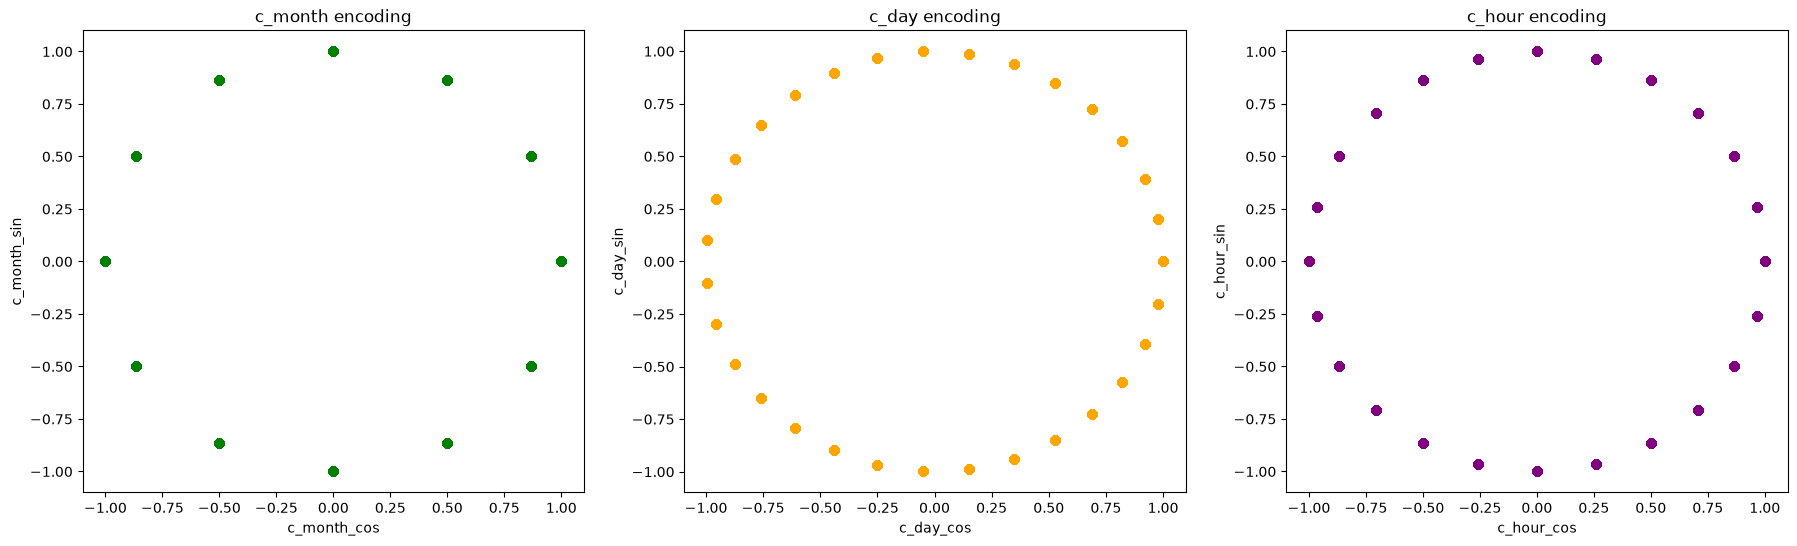

,c_month_cos,c_month_sin,c_day_cos,c_day_sin,c_hour_cos,c_hour_sin
0,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
1,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
2,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
3,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
4,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819


In [40]:
from sklearn.preprocessing import FunctionTransformer
time_features = ['created',]

# custom functions for pipeline
def extract_features(X):
    """
    Creates the `c_month`, `c_day`, and `c_hour` columns using the `created` column.

    Params:
        X: The `created` column.

    Returns:
        df: A `pd.DataFrame` containing `c_month`, `c_day`, and `c_hour`.
    """

    df = pd.DataFrame()

    df['c_month'] = X['created'].dt.month
    df['c_day'] = X['created'].dt.day
    df['c_hour'] = X['created'].dt.hour

    return df

def create_cyclical_encoding(X):
    """
    Cyclically encodes `c_month`, `c_day`, and `c_hour`.capitalize

    Params:
        X: A `pd.DataFrame` containing `c_month`, `c_day`, and `c_hour`.

    Returns:
        res: A `np.ndarray` containing `c_month_sin`, `c_month_cos`, `c_day_sin`, `c_day_cos`, `c_hour_sin`, and `c_hour_cos` columns.
    """

    # grabs cols
    months = X['c_month'] # [1, 12]
    days = X['c_day'] # [1, 31]
    hours = X['c_hour'] # [0, 23]

    # transform
    c_month_cos = np.cos(months * (2*np.pi / 12))
    c_month_sin = np.sin(months * (2*np.pi / 12))

    c_day_cos = np.cos(days * (2*np.pi / 31))
    c_day_sin = np.sin(days * (2*np.pi / 31))

    c_hour_cos = np.cos(hours * (2*np.pi / 24))
    c_hour_sin = np.sin(hours * (2*np.pi / 24))

    return np.column_stack([c_month_cos, c_month_sin, c_day_cos, c_day_sin, c_hour_cos, c_hour_sin])

# used to retain feature names
def extractor_feature_names_out(function_transformer, input_features):
    return ['c_month', 'c_day', 'c_hour']

def cyclical_feature_names_out(function_transformer, input_features):
    return ['c_month_cos', 'c_month_sin', 'c_day_cos', 'c_day_sin', 'c_hour_cos', 'c_hour_sin']

extractor = FunctionTransformer(extract_features, feature_names_out=extractor_feature_names_out)
cyclical_encoder = FunctionTransformer(create_cyclical_encoding, feature_names_out=cyclical_feature_names_out)

time_pipeline = Pipeline([
    ('extract_features', extractor),
    ('cyclical', cyclical_encoder)
    ],
)

# test 
time_test = df[time_features]
time_pipeline.fit(time_test)
time_test_res = time_pipeline.transform(time_test)

# plotting results for understanding
_, ax = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

ax[0].scatter(time_test_res[:, 0], time_test_res[:, 1], color='green')
ax[0].set(title='c_month encoding', xlabel='c_month_cos', ylabel='c_month_sin')

ax[1].scatter(time_test_res[:, 2], time_test_res[:, 3], color='orange')
ax[1].set(title='c_day encoding', xlabel='c_day_cos', ylabel='c_day_sin')

ax[2].scatter(time_test_res[:, 4], time_test_res[:, 5], color='purple')
ax[2].set(title='c_hour encoding', xlabel='c_hour_cos', ylabel='c_hour_sin')
plt.show()

pd.DataFrame(time_test_res, columns=time_pipeline.get_feature_names_out()).head()

## Pipeline Aggregation
Here we will combine all transformation pipelines into one singular `ColumnTransformer`

In [41]:
pipe = ColumnTransformer(
    [
        ('categorical', cat_pipeline, cat_features),
        ('zipcode', zip_pipeline, zip_features),
        ('cyclical', time_pipeline, time_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

X = df.drop(['resolution_time'], axis=1)
y = df['resolution_time']

pipe.fit(X, y)
pipe_res = pipe.transform(X)

pd.DataFrame(pipe_res.toarray(), columns=pipe.get_feature_names_out()).head()

,problem_Animal-Abuse,problem_Bike/Roller/Skate,problem_Bike/Roller/Skate Chronic,problem_Blocked Driveway,problem_Disorderly Youth,problem_Drinking,problem_Drug Activity,problem_Encampment,problem_Graffiti,problem_Illegal Fireworks,...,method_OTHER,method_PHONE,method_UNKNOWN,zipcode,c_month_cos,c_month_sin,c_day_cos,c_day_sin,c_hour_cos,c_hour_sin
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.961151,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.923430,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.040927,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.020683,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.923430,1.0,-2.449294e-16,1.0,-2.449294e-16,0.965926,-0.258819


# Conclusion
In this notebook, we created a feature preprocessing pipeline. Next, we can select models to try on 
this dataset, we will again focus on three different agencies. This is to verify whether or not
different agencies would benefit from using different types of models. We will hypothesize a set of 
machine learning models, and test the bare-bones results of them before *feature selection* or 
*hyperparameter tuning*. 

Prior to beginning the next step, we will **dump** our preprocessing pipeline so that we can access 
it in the next notebook, [`model_selection.ipynb`](/notebooks/model_selection.ipynb).

In [42]:
from sklearn.base import clone
import cloudpickle as cp

with open('../models/preprocessing_pipeline.pkl', 'wb') as f:
    pipeline = clone(pipe) # create a fresh, untrained pipeline
    cp.dump(pipeline, f)